In [1]:
import os
import sys
import argparse
import random

import matplotlib.pyplot as plt

from data import *
from utils import *
from datetime import datetime

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Attack'))

from BA import oh_binary_accuracy

from FGSM import FGSM

In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=10_000, help='Total # of samples')                     # Maybe 10_000
parser.add_argument('--mb_size', type=int, default=128, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=24, help='Dim of latent vector')                   # Maybe 16, 32
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')   # Maybe 16, 48 or 64 if too blurry
parser.add_argument('--x_fdim', type=int, default=48, help='Input x_fdim. See utils.py')            # Maybe 96 or 128
parser.add_argument('--y_fdim', type=int, default=16, help='Input y_fdim. See utils.py')            # Maybe 10, 16, 20, 32
parser.add_argument('--c_accu', type=float, default=25, help='Input weight on recons_error')        # Maybe 10, 25, 50, 100

# Training Settings =============================
parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')     # Maybe 3e-4, 1e-4, 5e-5
parser.add_argument('--max_epochs', type=int, default=500, help='Input max_epoch for cut-off')
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

In [3]:
_, xtest, _, _ = get_mnist_dataloader(args=opt)

In [4]:
model = torch.load('out/Final.tar', weights_only=False)
model_1V = torch.load('out/Final-1V.tar', weights_only=False)

net1 = model['net1']
net2 = model['net2']
net3 = model['net3']
net4 = model['net4']

net1_1V = model_1V['net1']
net3_1V = model_1V['net3']

net1.eval()
net2.eval()
net3.eval()
net4.eval()
net1_1V.eval()
net3_1V.eval()

Net3(
  (fc1): Linear(in_features=48, out_features=3136, bias=True)
  (conv2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv1): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
)

In [5]:
def kPCA_1V(X, eps=1e-6):
    a = X @ X.T
    B = a.size(0)

    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    a = 0.5 * (a + a.T)  # numerical symmetry
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    return evecs[:, :opt.h_dim], evals

In [6]:
def kPCA_2V(X, Y, eps=1e-6):
    a = X @ X.T + Y @ Y.T
    B = a.size(0)

    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    a = 0.5 * (a + a.T)  # numerical symmetry
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    return evecs[:, :opt.h_dim], evals

In [7]:
FGSM_1V = FGSM(net_in1=net1_1V, net_out1=net3_1V, kPCA=kPCA_1V, opt=opt)
FGSM_2V = FGSM(net_in1=net1, net_in2=net2, net_out1=net3, net_out2=net4, kPCA=kPCA_2V, opt=opt)

## Attack
### Clean Reconstruction

In [8]:
datax, datay = next(iter(xtest))   # full first test batch
datax = datax.to(opt.device).double()
datay = datay.to(opt.device).double()

# originals for plotting
in_data_x_test = datax[:10].detach().cpu().numpy()
in_data_y_test = datay[:10].detach().cpu().numpy()

# clean reconstruction with full-batch kPCA
with torch.no_grad():
    x_en = net1(datax)
    y_en = net2(datay)
    x_en_1V = net1_1V(datax)

    _h, _ = kPCA_2V(x_en, y_en)
    _h_1V, _ = kPCA_1V(x_en_1V)

    U = torch.mm(x_en.t(), _h)
    V = torch.mm(y_en.t(), _h)
    U_1V = torch.mm(x_en_1V.t(), _h_1V)

    x_tilde = net3(torch.mm(_h, U.t()))
    y_tilde = net4(torch.mm(_h, V.t()))
    x_tilde_1V = net3_1V(torch.mm(_h_1V, U_1V.t()))

out_data_x_test = x_tilde.detach().cpu().numpy()
out_data_x_test_1V = x_tilde_1V.detach().cpu().numpy()
out_data_y_test = y_tilde.detach().cpu().numpy()

### Attacked Reconstruction

In [9]:
epsilon = 0.2

#! Define adversarial batches                                                   ---
fgsm_batch, _ = FGSM_2V.create_adversarial_batch_fgsm(in1=datax, in2=datay, epsilon=epsilon)
bim_batch, _ = FGSM_2V.create_adversarial_batch_bim(in1=datax, in2=datay, epsilon=epsilon, alpha=0.1, num_iterations=10)
# lbfgs_batch, _ = FGSM_2V.create_adversarial_batch_lbfgs(in1=datax, in2=datay, epsilon=epsilon, num_steps=50)

fgsm_1v_batch, _ = FGSM_1V.create_adversarial_batch_fgsm(in1=datax, epsilon=epsilon)
fgsm_2v_batch, _ = FGSM_2V.create_adversarial_batch_fgsm(in1=datax, in2=datay, epsilon=epsilon)

#! Run models on adversarial batches and get reconstructions                    ---
with torch.no_grad():
    fgsm_x_tilde, fgsm_y_tilde, _ = FGSM_2V.run_model_batch(b1=fgsm_batch, b2=datay)     # Digit + label reconstruction for FGSM attack
    bim_x_tilde, bim_y_tilde, _ = FGSM_2V.run_model_batch(b1=bim_batch, b2=datay)        #                                  BIM  attack
    # lbfgs_x_tilde, lbfgs_y_tilde, _ = FGSM_2V.run_model_batch(b1=lbfgs_batch, b2=datay)  #                                  L-BFGS attack

    fgsm_1V_x_tilde, _, _ = FGSM_1V.run_model_batch(b1=fgsm_1v_batch)                 # Digit reconstruction for FGSM attack on 1V model
    bim_1V_x_tilde, _, _ = FGSM_1V.run_model_batch(b1=bim_batch)                      #                          BIM  attack


#! Prepare data for plotting                                                     ---
adv_data_x_test = fgsm_batch[:10].detach().cpu().numpy()                        # Save ground truth
perturbations = (fgsm_batch[:10] - datax[:10]).detach().cpu().numpy()           # Perturbation (adversarial noise)

fgsm_out_X = fgsm_x_tilde[:10].detach().cpu().numpy()                           # FGSM X
fgsm_out_y = fgsm_y_tilde[:10].detach().cpu().numpy()                           #      y

bim_out = bim_x_tilde[:10].detach().cpu().numpy()                               # BIM X
bim_out_y = bim_y_tilde[:10].detach().cpu().numpy()                             #     y

# lbfgs_out_X = lbfgs_x_tilde[:10].detach().cpu().numpy()                         # L-BFGS X 
# lbfgs_out_y = lbfgs_y_tilde[:10].detach().cpu().numpy()                         #        y


fgsm_1v_out = fgsm_1V_x_tilde[:10].detach().cpu().numpy()                       # FGSM-1V X
bim_1v_out = bim_1V_x_tilde[:10].detach().cpu().numpy()                         # BIM-1V X


### Loss Calculation

In [11]:
recon_loss = torch.nn.MSELoss(reduction='mean')
B = datax.size(0)

#! Clean batch losses                                                           ---
clean_digit_loss = recon_loss(x_tilde.view(B, -1), datax.view(B, -1))           # Digit reconstruction loss
clean_label_loss = 1 - oh_binary_accuracy(                                      # Label reconstruction loss (accuracy-based)
    datay.detach().cpu().numpy(),
    y_tilde.view(B, -1).detach().cpu().numpy()
)

#! Adversarial batch losses                                                     ---   
#  FGSM 
fgsm_adv_digit_loss = recon_loss(fgsm_x_tilde.view(B, -1), datax.view(B, -1))   # Digit reconstruction FGSM
fgsm_adv_label_loss = 1 - oh_binary_accuracy(                                   # Label reconstruction loss (accuracy-based)
    datay.detach().cpu().numpy(),
    fgsm_y_tilde.view(B, -1).detach().cpu().numpy()
)

#!  BIM                                                                         ---
bim_adv_digit_loss = recon_loss(bim_x_tilde.view(B, -1), datax.view(B, -1))     # Digit reconstruction BIM
bim_adv_label_loss = 1 - oh_binary_accuracy(                                    # Label reconstruction loss (accuracy-based)
    datay.detach().cpu().numpy(),
    bim_y_tilde.view(B, -1).detach().cpu().numpy()
)

# #!  L-BFGS                                                                      ---
# lbfgs_adv_digit_loss = recon_loss(lbfgs_x_tilde.view(B, -1), datax.view(B, -1)) # Digit reconstruction L-BFGS
# lbfgs_adv_label_loss = 1 - oh_binary_accuracy(                                  # Label reconstruction loss (accuracy-based)
#     datay.detach().cpu().numpy(),
#     lbfgs_y_tilde.view(B, -1).detach().cpu().numpy()
# )


clean_total_loss = (clean_digit_loss.item() + clean_label_loss) / 2             # Total loss as average of the two
fgsm_total_loss = (fgsm_adv_digit_loss.item() + fgsm_adv_label_loss) / 2
bim_total_loss = (bim_adv_digit_loss.item() + bim_adv_label_loss) / 2
# lbfgs_total_loss = (lbfgs_adv_digit_loss.item() + lbfgs_adv_label_loss) / 2         

In [12]:
# Loss values for the 1V model
clean_digit_loss_1V = recon_loss(x_tilde_1V.view(B, -1), datax.view(B, -1))
fgsm_1V_loss = recon_loss(fgsm_1V_x_tilde.view(B, -1), datax.view(B, -1))
bim_1V_loss = recon_loss(bim_1V_x_tilde.view(B, -1), datax.view(B, -1))

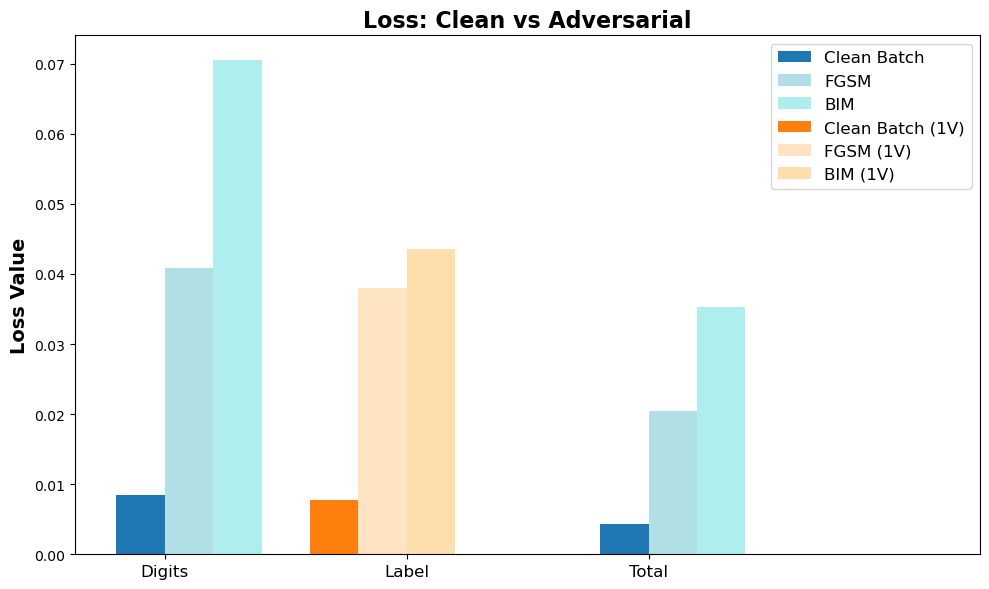

FGSM Loss Increase: +381.26%
BIM Loss Increase: +729.52%
FGSM 1V Loss Increase: +393.94%
BIM 1V Loss Increase: +465.41%


In [13]:
categories = ['Digits', 'Label', 'Total']
clean_losses = [clean_digit_loss.item(), clean_label_loss.item(), clean_total_loss]
fgsm_losses = [fgsm_adv_digit_loss.item(), fgsm_adv_label_loss.item(), fgsm_total_loss]
bim_losses = [bim_adv_digit_loss.item(), bim_adv_label_loss.item(), bim_total_loss]
# lbfgs_losses = [lbfgs_adv_digit_loss.item(), lbfgs_adv_label_loss.item(), lbfgs_total_loss]

fgsm_1v_clean_losses = [clean_digit_loss_1V.item(), 0, 0]
fgsm_1v_losses = [fgsm_1V_loss.item(), 0, 0]
bim_1v_losses = [bim_1V_loss.item(), 0, 0]

x = list(range(len(categories)))
width = 0.2

plt.figure(figsize=(10, 6))

# Main bars for all categories
plt.bar([i - width/2 for i in x], clean_losses, width=width, label='Clean Batch', color='tab:blue')
plt.bar([i + width/2 for i in x], fgsm_losses,   width=width, label='FGSM', color='powderblue')
plt.bar([i + 1.5*width for i in x], bim_losses,   width=width, label='BIM', color='paleturquoise')
# plt.bar([i + 2.5*width for i in x], lbfgs_losses, width=width, label='L-BFGS', color='lightcyan')
plt.bar([i + 3.5*width for i in x], fgsm_1v_clean_losses, width=width, label='Clean Batch (1V)', color='tab:orange')
plt.bar([i + 4.5*width for i in x], fgsm_1v_losses, width=width, label='FGSM (1V)', color='bisque')
plt.bar([i + 5.5*width for i in x], bim_1v_losses, width=width, label='BIM (1V)', color='navajowhite')


plt.xticks(x, categories, fontsize=12)
plt.title('Loss: Clean vs Adversarial', fontsize=16, weight='bold')
plt.ylabel('Loss Value', fontsize=14, weight='bold')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f'FGSM Loss Increase: +{((fgsm_total_loss - clean_total_loss) / clean_total_loss) * 100:.2f}%')
print(f'BIM Loss Increase: +{((bim_total_loss - clean_total_loss) / clean_total_loss) * 100:.2f}%')
print(f'FGSM 1V Loss Increase: +{((fgsm_1V_loss.item() - clean_digit_loss_1V.item()) / clean_digit_loss_1V.item()) * 100:.2f}%')
print(f'BIM 1V Loss Increase: +{((bim_1V_loss.item() - clean_digit_loss_1V.item()) / clean_digit_loss_1V.item()) * 100:.2f}%')

In [14]:
def mse(x, y):
    return round(np.mean((x - y) ** 2), 2)

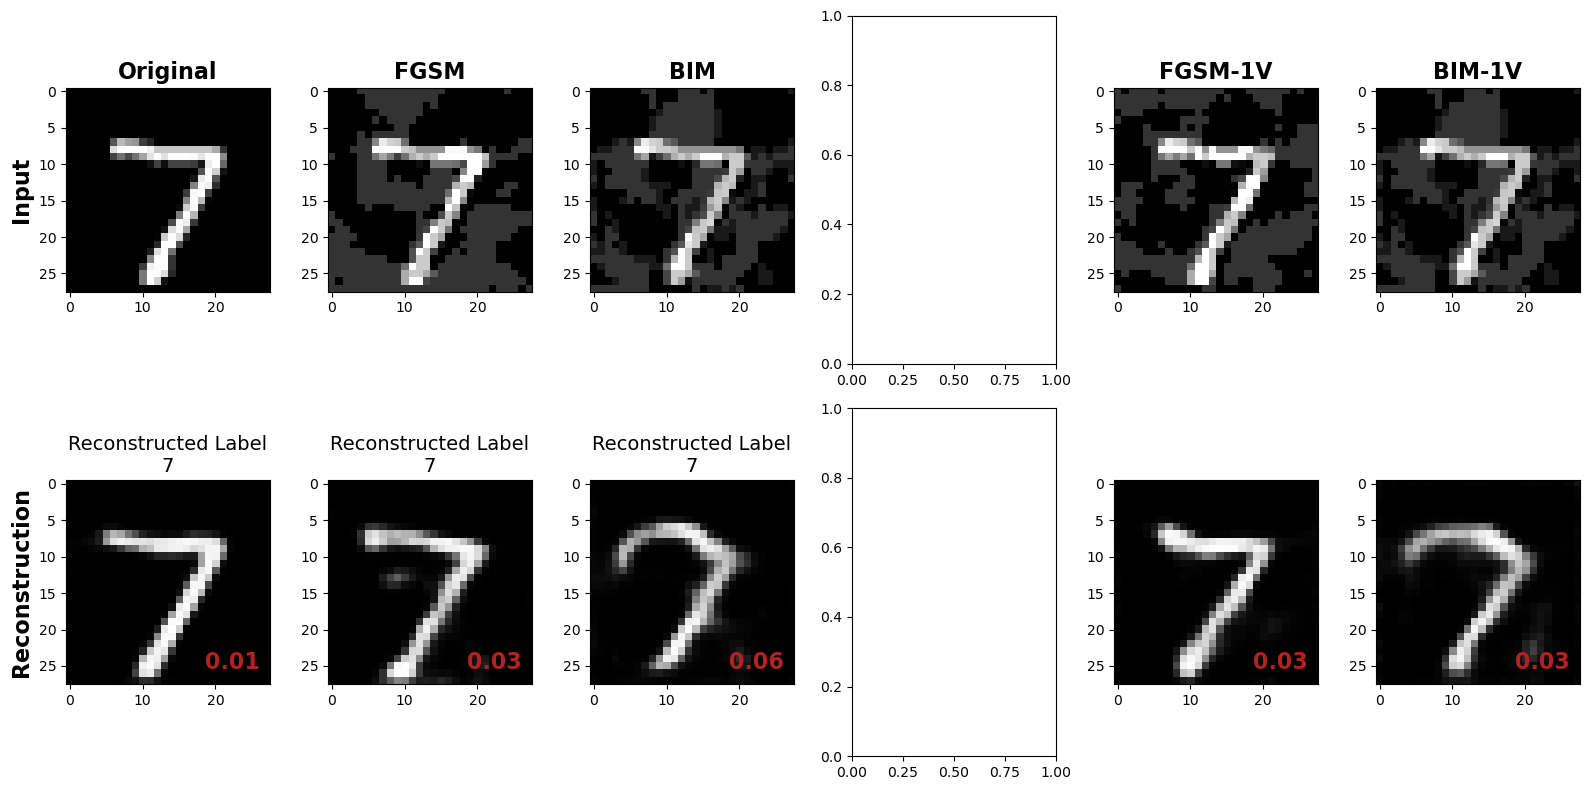

In [16]:
fig, axes = plt.subplots(2, 6, figsize=(16, 8))

# Add y labels for the rows
axes[0, 0].set_ylabel('Input', fontsize=16, weight='bold')
axes[1, 0].set_ylabel('Reconstruction', fontsize=16, weight='bold')

axes[0, 0].set_title('Original', fontsize=16, weight='bold')
axes[0, 0].imshow(in_data_x_test[0].reshape(28, 28), cmap='gray')

axes[0, 1].set_title('FGSM', fontsize=16, weight='bold')
axes[0, 1].imshow(fgsm_batch[0].reshape(28, 28), cmap='gray')

axes[0, 2].set_title('BIM', fontsize=16, weight='bold')
axes[0, 2].imshow(bim_batch[0].reshape(28, 28), cmap='gray')

# axes[0, 3].set_title('L-BFGS', fontsize=16, weight='bold')
# axes[0, 3].imshow(lbfgs_batch[0].reshape(28, 28), cmap='gray')

axes[0, 4].set_title('FGSM-1V', fontsize=16, weight='bold')
axes[0, 4].imshow(fgsm_1v_batch[0].reshape(28, 28), cmap='gray')

axes[0, 5].set_title('BIM-1V', fontsize=16, weight='bold')
axes[0, 5].imshow(bim_batch[0].reshape(28, 28), cmap='gray')

axes[1, 0].set_title(f'Reconstructed Label\n{out_data_y_test[0].argmax()}', fontsize=14)
axes[1, 0].imshow(out_data_x_test[0].reshape(28, 28), cmap='gray')
axes[1, 0].text(0.95, 0.05, f'{mse(out_data_x_test[0], in_data_x_test[0])}', color='firebrick', fontsize=16, weight='bold', ha='right', va='bottom', transform=axes[1, 0].transAxes)

axes[1, 1].set_title(f'Reconstructed Label\n{fgsm_out_y[0].argmax()}', fontsize=14)
axes[1, 1].imshow(fgsm_out_X[0].reshape(28, 28), cmap='gray')
axes[1, 1].text(0.95, 0.05, f'{mse(fgsm_out_X[0], in_data_x_test[0])}', color='firebrick', fontsize=16, weight='bold', ha='right', va='bottom', transform=axes[1, 1].transAxes)

axes[1, 2].set_title(f'Reconstructed Label\n{bim_out_y[0].argmax()}', fontsize=14)
axes[1, 2].imshow(bim_out[0].reshape(28, 28), cmap='gray')
axes[1, 2].text(0.95, 0.05, f'{mse(bim_out[0], in_data_x_test[0])}', color='firebrick', fontsize=16, weight='bold', ha='right', va='bottom', transform=axes[1, 2].transAxes)

# axes[1, 3].set_title(f'Reconstructed Label\n{lbfgs_out_y[0].argmax()}', fontsize=14)
# axes[1, 3].imshow(lbfgs_out_X[0].reshape(28, 28), cmap='gray')
# axes[1, 3].text(0.95, 0.05, f'{mse(lbfgs_out_X[0], in_data_x_test[0])}', color='firebrick', fontsize=16, weight='bold', ha='right', va='bottom', transform=axes[1, 3].transAxes)

axes[1, 4].imshow(fgsm_1v_out[0].reshape(28, 28), cmap='gray')
axes[1, 4].text(0.95, 0.05, f'{mse(fgsm_1v_out[0], in_data_x_test[0])}', color='firebrick', fontsize=16, weight='bold', ha='right', va='bottom', transform=axes[1, 4].transAxes)

axes[1, 5].imshow(bim_1v_out[0].reshape(28, 28), cmap='gray')
axes[1, 5].text(0.95, 0.05, f'{mse(bim_1v_out[0], in_data_x_test[0])}', color='firebrick', fontsize=16, weight='bold', ha='right', va='bottom', transform=axes[1, 5].transAxes)

plt.tight_layout()
plt.show()